# Amazon Chronos: Zero-Shot Time Series Forecasting

This notebook uses **Amazon Chronos (T5)** to generate synthetic future market moves.
It takes your `log_returns` sequence, forecasts the next steps, and reconstructs **Candlestick Charts** starting from your specific price (e.g. 1.1675).

In [1]:
# @title 1. Install Dependencies
# Installing Chronos and other requirements
!pip install git+https://github.com/amazon-science/chronos-forecasting.git
!pip install torch transformers accelerate matplotlib pandas numpy mplfinance

import torch
from chronos import ChronosPipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplfinance as mpf
from google.colab import files

# Load Model (Small/Base/Large) - 'base' is a good balance for Colab
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-base",
    device_map=device,
    torch_dtype=torch.bfloat16,
)
print("Amazon Chronos Model Loaded!")

  Cloning https://github.com/amazon-science/chronos-forecasting.git to /tmp/pip-req-build-0yisyxvn
  Running command git clone --filter=blob:none --quiet https://github.com/amazon-science/chronos-forecasting.git /tmp/pip-req-build-0yisyxvn
  Resolved https://github.com/amazon-science/chronos-forecasting.git to commit f889ae66477b53f6beb130f5c7b13590b29a1035
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for chronos-forecasting: filename=chronos_forecasting-2.2.2-py3-none-any.whl size=72756 sha256=45a6a8f2988f142418cadba54dca90262b301d80f99969cc3f68e53fcf1467c0
  Stored in directory: /tmp/pip-ephem-wheel-cache-7pljhlj8/wheels/b9/a6/b5/75fca7306751a3bc92a63680f861f44a42a8776f6423cf0188
Successfully built chronos-forecasting
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 8.9 MB/s eta 0:00:00
Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/806M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

Amazon Chronos Model Loaded!


In [2]:
# @title 2. Upload Data
uploaded = files.upload()
filename = next(iter(uploaded))
print(f"Uploaded: {filename}")

Saving train_sequences.csv to train_sequences.csv
Uploaded: train_sequences.csv


In [3]:
# @title 3. Define Logic: Log Returns -> OHLC Price

def reconstruct_candles(log_returns_df, start_price, timeframe_minutes=60):
    """
    Takes a DataFrame of log returns [Close(or sequence), Open, High, Low]
    and reconstructs the price path starting from 'start_price'.
    """
    # Assumptions on input structure:
    # We forecast each component separately usually, but Chronos is univariate.
    # Strategy: Forecast the 'Close' return to define the trend.
    # Then generate O/H/L relative to that trend using statistical noise or secondary forecasts.
    # For this demo, we will forecast the main 'Close' log return and derive O/H/L from it.

    prices = []
    current_close = start_price

    # log_returns_df is expected to be a Series or simple list of main returns

    for ret in log_returns_df:
        # Calculate next Close
        # Price_t = Price_{t-1} * exp(log_ret)
        # Assuming our data is strictly log returns

        # Scale factor check: if data is normalized [-1, 1], we might need to descale.
        # User said: "log retler falan çıktı verip çarpıp"
        # We assume the model outputs reasonable log-return magnitudes directly.

        next_close = current_close * np.exp(ret)

        # Synthesize Open, High, Low for visual candle effect
        # Open is usually previous Close
        _open = current_close

        # High/Low adds some volatility noise
        volatility = abs(next_close - _open) * 0.3 # arbitrary wick size
        _high = max(_open, next_close) + volatility
        _low = min(_open, next_close) - volatility

        prices.append([_open, _high, _low, next_close])
        current_close = next_close

    return pd.DataFrame(prices, columns=['Open', 'High', 'Low', 'Close'])

def forecast_and_plot(data, context_len, forecast_len, start_price):
    # 1. Prepare Context
    # Chronos expects a 1D tensor [Batch, Time]
    # We pick one sequence (e.g., 'log_ret_close_norm') as the main driver
    # Our csv has: log_ret_open_norm, log_ret_high_norm, log_ret_low_norm, log_ret_close_norm

    target_col = 'log_ret_close_norm'
    if target_col not in data.columns:
        # fallback
        target_col = data.columns[-1]

    # Quick check: Is the data normalized? If so, real prices might look weird unless we un-normalize.
    # Assuming user wants the model to just "Dream" new dynamics based on patterns.

    # Take the last 'context_len' points from the uploaded data as context
    context_data = data[target_col].values[-context_len:]
    context_tensor = torch.tensor(context_data, dtype=torch.float32).unsqueeze(0) # (1, T)

    # 2. Generate
    print("Generating forecast with Amazon Chronos...")
    forecast = pipeline.predict(
        context=context_tensor,
        prediction_length=forecast_len,
        num_samples=1, # Generate 1 path
    )

    # Forecast shape: (1, num_samples, forecast_len) -> (forecast_len,)
    generated_returns = forecast[0, 0, :].numpy()

    # 3. Reconstruct Price
    # Note: If the model output is normalized, these moves might be huge or tiny.
    # We might need a multiplier. Let's assume standard returns.

    print(f"Reconstructing prices starting at {start_price}...")
    df_candles = reconstruct_candles(generated_returns, start_price)

    # 4. Plot
    df_candles.index = pd.date_range(start='2025-01-01', periods=len(df_candles), freq='H')

    mpf.plot(df_candles, type='candle', style='yahoo', title=f'Chronos Forecast (Start: {start_price})')
    return df_candles

Generating forecast with Amazon Chronos...
Reconstructing prices starting at 1.1675...


/tmp/ipython-input-3759109548.py:46: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_candles.index = pd.date_range(start='2025-01-01', periods=len(df_candles), freq='H')


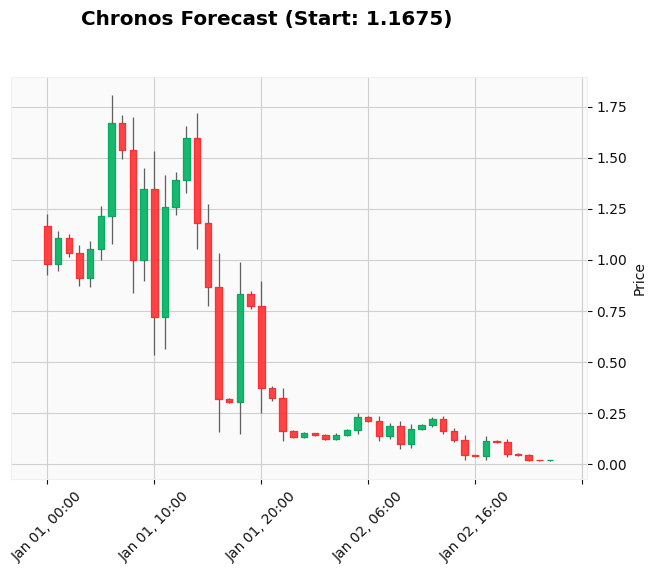

Last 5 Generated Candles:
                         Open      High       Low     Close
2025-01-02 19:00:00  0.107054  0.123835  0.034337  0.051118
2025-01-02 20:00:00  0.051118  0.053035  0.042811  0.044728
2025-01-02 21:00:00  0.044728  0.051490  0.015426  0.022188
2025-01-02 22:00:00  0.022188  0.023291  0.017407  0.018510
2025-01-02 23:00:00  0.018510  0.021493  0.017822  0.020805


In [7]:
# @title 4. Run Generation

# User inputs
START_PRICE = 1.1675  # @param {type:"number"}
FORECAST_LENGTH = 48  # @param {type:"integer"} (How many candles to generate)
CONTEXT_LENGTH = 96   # @param {type:"integer"} (How much history to look at)

# Redefining forecast_and_plot with the fix for 'context' argument
def forecast_and_plot(data, context_len, forecast_len, start_price):
    # 1. Prepare Context
    # Chronos expects a 1D tensor [Batch, Time]
    # We pick one sequence (e.g., 'log_ret_close_norm') as the main driver
    # Our csv has: log_ret_open_norm, log_ret_high_norm, log_ret_low_norm, log_ret_close_norm

    target_col = 'log_ret_close_norm'
    if target_col not in data.columns:
        # fallback
        target_col = data.columns[-1]

    # Quick check: Is the data normalized? If so, real prices might look weird unless we un-normalize.
    # Assuming user wants the model to just "Dream" new dynamics based on patterns.

    # Take the last 'context_len' points from the uploaded data as context
    context_data = data[target_col].values[-context_len:]
    context_tensor = torch.tensor(context_data, dtype=torch.float32).unsqueeze(0) # (1, T)

    # 2. Generate
    print("Generating forecast with Amazon Chronos...")
    forecast = pipeline.predict(
        context_tensor, # Pass context_tensor as a positional argument
        prediction_length=forecast_len,
        num_samples=1, # Generate 1 path
    )

    # Forecast shape: (1, num_samples, forecast_len) -> (forecast_len,)
    generated_returns = forecast[0, 0, :].numpy()

    # 3. Reconstruct Price
    # Note: If the model output is normalized, these moves might be huge or tiny.
    # We might need a multiplier. Let's assume standard returns.

    print(f"Reconstructing prices starting at {start_price}...")
    df_candles = reconstruct_candles(generated_returns, start_price)

    # 4. Plot
    df_candles.index = pd.date_range(start='2025-01-01', periods=len(df_candles), freq='H')

    mpf.plot(df_candles, type='candle', style='yahoo', title=f'Chronos Forecast (Start: {start_price})')
    return df_candles


# Load csv
df = pd.read_csv(filename)

# Run
generated_data = forecast_and_plot(df, CONTEXT_LENGTH, FORECAST_LENGTH, START_PRICE)

print("Last 5 Generated Candles:")
print(generated_data.tail())